# SegFormer B5 — Coralscapes inference (1024×1024)

This notebook loads **[EPFL-ECEO/segformer-b5-finetuned-coralscapes-1024-1024](https://huggingface.co/EPFL-ECEO/segformer-b5-finetuned-coralscapes-1024-1024)** (SegFormer + MiT-B5, fine-tuned on [Coralscapes](https://huggingface.co/datasets/EPFL-ECEO/coralscapes)).

**What the model predicts**

| Item | Detail |
|------|--------|
| Output channels | **40** (`model.config.num_labels`) |
| Label **0** | **unlabeled** (void / not one of the benthic IDs; ignored in official eval) |
| Labels **1–39** | The **39 benthic classes** (same IDs as `classes.json` in the Coralscapes release) |

**Dataset context:** ~2k reef images at 1024×2048, Red Sea sites; dense polygons for substrate, corals (live/dead/bleached), fish, divers, tools, etc. Reported test metrics for this checkpoint: **pixel acc ~82.8%**, **mIoU ~57.8** (model card).

**Inference:** For images not close to 1024×1024, the authors recommend a **sliding window** over 1024×1024 crops (implemented below). For small crops you can use single forward pass + `post_process_semantic_segmentation`.

Colors below come from **`data/coralscapes/colors.json`** when present; label names from **`data/coralscapes/classes.json`**.

**Run:** *Kernel → Restart Kernel and Run All* (top to bottom). Set `VIDEO_PATH` (video cell) and/or `IMAGE_PATH` (image cells) before running inference.

In [ ]:
# Optional: install if needed (uncomment in a fresh environment)
# %pip install -q torch torchvision transformers pillow numpy matplotlib accelerate huggingface_hub opencv-python-headless

# Run cells in order from top (Kernel → Restart & Run All). If you see id2label errors, rerun from the imports cell.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from transformers import SegformerConfig, SegformerForSemanticSegmentation, SegformerImageProcessor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

MODEL_ID = "EPFL-ECEO/segformer-b5-finetuned-coralscapes-1024-1024"


def _repo_root() -> Path:
    p = Path.cwd().resolve()
    if (p / "data" / "coralscapes" / "classes.json").is_file():
        return p
    if (p.parent / "data" / "coralscapes" / "classes.json").is_file():
        return p.parent
    return p


PROJECT_ROOT = _repo_root()
CORALSCAPES_DIR = PROJECT_ROOT / "data" / "coralscapes"

c:\Users\sable\.pyenv\pyenv-win\versions\3.12.4\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


In [2]:
def load_coralscapes_label_maps(coral_dir: Path) -> tuple[dict[int, str], dict[int, list[int]]]:
    """Build id -> name and id -> RGB using Coralscapes JSON (0 = unlabeled)."""
    id2label: dict[int, str] = {0: "unlabeled"}
    id2color: dict[int, list[int]] = {0: [255, 255, 255]}

    classes_path = coral_dir / "classes.json"
    colors_path = coral_dir / "colors.json"
    if classes_path.is_file():
        name_to_id: dict[str, int] = json.loads(classes_path.read_text(encoding="utf-8"))
        for name, cid in name_to_id.items():
            id2label[int(cid)] = name
    else:
        print(f"Warning: missing {classes_path}; names only for 0..39 from model config.")

    if colors_path.is_file():
        name_to_color: dict[str, list[int]] = json.loads(colors_path.read_text(encoding="utf-8"))
        for cid, name in list(id2label.items()):
            if cid == 0:
                continue
            if name in name_to_color:
                id2color[cid] = name_to_color[name]
    # Fill any missing IDs with a stable pseudo color
    for cid in range(40):
        if cid not in id2color:
            rng = np.random.default_rng(cid + 42)
            id2color[cid] = [int(x) for x in rng.integers(30, 255, size=3)]
    return id2label, id2color


id2label, id2color = load_coralscapes_label_maps(CORALSCAPES_DIR)

print(f"Defined {len(id2label)} label names (0 = unlabeled, 1–39 = benthic).")
print("\nClass list (id: name):")
for i in sorted(id2label.keys()):
    print(f"  {i:2d}  {id2label[i]}")

Defined 40 label names (0 = unlabeled, 1–39 = benthic).

Class list (id: name):
   0  unlabeled
   1  seagrass
   2  trash
   3  other coral dead
   4  other coral bleached
   5  sand
   6  other coral alive
   7  human
   8  transect tools
   9  fish
  10  algae covered substrate
  11  other animal
  12  unknown hard substrate
  13  background
  14  dark
  15  transect line
  16  massive/meandering bleached
  17  massive/meandering alive
  18  rubble
  19  branching bleached
  20  branching dead
  21  millepora
  22  branching alive
  23  massive/meandering dead
  24  clam
  25  acropora alive
  26  sea cucumber
  27  turbinaria
  28  table acropora alive
  29  sponge
  30  anemone
  31  pocillopora alive
  32  table acropora dead
  33  meandering bleached
  34  stylophora alive
  35  sea urchin
  36  meandering alive
  37  meandering dead
  38  crown of thorn
  39  dead clam


In [3]:
# Hub config has invalid id2label (int values). Pop label maps before from_dict; assign names after.
import shutil
import tempfile

from huggingface_hub import hf_hub_download

_pp_path = hf_hub_download(repo_id=MODEL_ID, filename="preprocessor_config.json")
_tmp_pp = Path(tempfile.mkdtemp())
shutil.copy(_pp_path, _tmp_pp / "preprocessor_config.json")
processor = SegformerImageProcessor.from_pretrained(_tmp_pp.as_posix())

_cfg_path = hf_hub_download(repo_id=MODEL_ID, filename="config.json")
with open(_cfg_path, encoding="utf-8") as _f:
    _raw = json.load(_f)
_raw.pop("id2label", None)
_raw.pop("label2id", None)
# This checkpoint's config.json omits num_labels; the head size must match weights (40 classes: 0–39).
_n = max(id2label.keys()) + 1
_raw["num_labels"] = _n
config = SegformerConfig.from_dict(_raw)
config.id2label = {i: id2label.get(i, f"class_{i}") for i in range(_n)}
config.label2id = {name: i for i, name in config.id2label.items()}

model = SegformerForSemanticSegmentation.from_pretrained(MODEL_ID, config=config).to(device)
model.eval()

print(model.config.num_labels, "logits per pixel (40 => unlabeled + 39 benthic classes)")

Loading weights: 100%|██████████| 1172/1172 [00:00<00:00, 5030.00it/s]

40 logits per pixel (40 => unlabeled + 39 benthic classes)


In [4]:
def resize_image_keep_aspect(image: Image.Image, target_small_side: int = 1024) -> Image.Image:
    w, h = image.size
    if min(w, h) == target_small_side:
        return image
    if w < h:
        new_w, new_h = target_small_side, int(round(h * target_small_side / w))
    else:
        new_w, new_h = int(round(w * target_small_side / h)), target_small_side
    return image.resize((new_w, new_h), Image.BILINEAR)


def segment_image_sliding_window(
    image: Image.Image,
    preprocessor: SegformerImageProcessor,
    model: SegformerForSemanticSegmentation,
    crop_size: tuple[int, int] = (1024, 1024),
    num_classes: int | None = None,
) -> np.ndarray:
    """Overlapping 1024×1024 windows; averages logits then argmax. Returns H×W int mask (original resolution)."""
    if num_classes is None:
        num_classes = model.config.num_labels

    resized = resize_image_keep_aspect(image, 1024)
    w_res, h_res = resized.size
    img = torch.from_numpy(np.array(resized).transpose(2, 0, 1)).float().unsqueeze(0)
    _, _, h_img, w_img = img.shape
    h_crop, w_crop = crop_size

    h_grids = max(1, int(np.round(1.5 * h_img / h_crop)))
    w_grids = max(1, int(np.round(1.5 * w_img / w_crop)))
    h_stride = max(1, (h_img - h_crop + h_grids - 1) // (h_grids - 1)) if h_grids > 1 else h_crop
    w_stride = max(1, (w_img - w_crop + w_grids - 1) // (w_grids - 1)) if w_grids > 1 else w_crop

    preds = img.new_zeros((1, num_classes, h_img, w_img))
    count_mat = img.new_zeros((1, 1, h_img, w_img))

    for hi in range(h_grids):
        for wi in range(w_grids):
            y1 = hi * h_stride
            x1 = wi * w_stride
            y2 = min(y1 + h_crop, h_img)
            x2 = min(x1 + w_crop, w_img)
            y1 = max(y2 - h_crop, 0)
            x1 = max(x2 - w_crop, 0)
            crop = img[:, :, y1:y2, x1:x2]
            crop_pil = Image.fromarray(
                crop.squeeze(0).permute(1, 2, 0).byte().cpu().numpy(), mode="RGB"
            )
            with torch.no_grad():
                inputs = preprocessor(crop_pil, return_tensors="pt")
                inputs = {k: v.to(device) for k, v in inputs.items()}
                outputs = model(**inputs)
            logits = F.interpolate(
                outputs.logits,
                size=crop.shape[-2:],
                mode="bilinear",
                align_corners=False,
            )
            pad = (
                int(x1),
                int(preds.shape[3] - x2),
                int(y1),
                int(preds.shape[2] - y2),
            )
            preds += F.pad(logits.cpu(), pad)
            count_mat[:, :, y1:y2, x1:x2] += 1

    assert (count_mat == 0).sum() == 0
    preds = preds / count_mat
    pred_cls = preds.argmax(dim=1).to(torch.uint8)
    pred_up = F.interpolate(
        pred_cls.unsqueeze(0).float(),
        size=(h_res, w_res),
        mode="nearest",
    ).squeeze(0)
    mask = pred_up.squeeze(0).cpu().numpy().astype(np.int32)
    orig_w, orig_h = image.size
    if mask.shape != (orig_h, orig_w):
        mask_img = Image.fromarray(mask.astype(np.uint8), mode="L")
        mask_img = mask_img.resize((orig_w, orig_h), Image.NEAREST)
        mask = np.array(mask_img, dtype=np.int32)
    return mask


def colorize_mask(mask: np.ndarray, id2color: dict[int, list[int]]) -> np.ndarray:
    h, w = mask.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    for cid, col in id2color.items():
        rgb[mask == cid] = col
    return rgb


def mask_to_overlay(image: Image.Image, colored_mask: np.ndarray, alpha: float = 0.55) -> np.ndarray:
    base = np.array(image.convert("RGB"), dtype=np.float32) / 255.0
    cm = colored_mask.astype(np.float32) / 255.0
    out = (1 - alpha) * base + alpha * cm
    return np.clip(out * 255, 0, 255).astype(np.uint8)

## Video

In [ ]:
# Video: SegFormer per frame, then **6-class LUT** — overlay **classes 1–5** only (distinct colors); class 0 keeps original pixels.
# Requires: pip install opencv-python-headless
import sys

import cv2

sys.path.insert(0, str(PROJECT_ROOT / "lib"))
from coralscapes_6class_lut import build_lut, remap_mask

VIDEO_PATH = Path(r"C:\Users\sable\OneDrive\Desktop\coral\outputs\video.mp4")  # <-- set to your .mp4/.mov
OUTPUT_VIDEO_PATH = PROJECT_ROOT / "outputs" / "segmented_6class_labels_1to5_video.mp4"
MAX_FRAMES = None  # e.g. 120 to test on first 120 frames only; None = full video

assert VIDEO_PATH.is_file(), f"Video not found: {VIDEO_PATH.resolve()}"

cap = cv2.VideoCapture(str(VIDEO_PATH))
if not cap.isOpened():
    raise RuntimeError(f"Could not open video: {VIDEO_PATH}")

fps = cap.get(cv2.CAP_PROP_FPS)
if fps is None or fps <= 1e-3:
    fps = 24.0
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or 0

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
OUTPUT_VIDEO_PATH.parent.mkdir(parents=True, exist_ok=True)
writer = cv2.VideoWriter(str(OUTPUT_VIDEO_PATH), fourcc, fps, (w, h))
if not writer.isOpened():
    cap.release()
    raise RuntimeError("VideoWriter failed to open; try another fourcc or path.")

from tqdm.auto import tqdm

id2color_6 = {
    0: [20, 40, 120],
    1: [170, 255, 195],  # live coral
    2: [255, 220, 100],  # bleached
    3: [160, 60, 80],  # dead
    4: [12, 85, 35],  # algae
    5: [180, 140, 100],  # benthic substrate
}
_lut6 = build_lut(max_class_id=255)
_alpha_vid = 0.5

_classes_6 = PROJECT_ROOT / "data" / "coralscapes_6class_dataset" / "classes_6.json"
_name_to_id_6 = json.loads(_classes_6.read_text(encoding="utf-8"))
_id2label_6 = {int(v): k for k, v in _name_to_id_6.items()}
print("Saved video overlays 6-class ids 1–5:", ", ".join(f'{i}={_id2label_6[i]}' for i in range(1, 6)))
print("Class 0 (water/background) shows the original frame.")

pbar = tqdm(total=n_frames if n_frames > 0 else None, desc="Video frames", unit="f")
n_done = 0
try:
    while True:
        ret, frame_bgr = cap.read()
        if not ret:
            break
        if MAX_FRAMES is not None and n_done >= MAX_FRAMES:
            break
        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        pil = Image.fromarray(frame_rgb)
        with torch.inference_mode():
            seg = segment_image_sliding_window(pil, processor, model)
        seg6 = remap_mask(seg.astype(np.uint8), _lut6)
        base_rgb = np.array(pil.convert("RGB"), dtype=np.float32)
        overlay_rgb = base_rgb.copy()
        for _cid in range(1, 6):
            _m = seg6 == _cid
            _col = np.array(id2color_6[_cid], dtype=np.float32)
            overlay_rgb[_m] = (1 - _alpha_vid) * overlay_rgb[_m] + _alpha_vid * _col
        overlay_rgb = np.clip(overlay_rgb, 0, 255).astype(np.uint8)
        out_bgr = cv2.cvtColor(overlay_rgb, cv2.COLOR_RGB2BGR)
        writer.write(out_bgr)
        n_done += 1
        pbar.update(1)
finally:
    pbar.close()
    cap.release()
    writer.release()

print(f"Wrote {n_done} frames to {OUTPUT_VIDEO_PATH.resolve()}")


Saved video overlays 6-class ids 1–5: 1=Live Coral, 2=Bleached Coral, 3=Dead Coral, 4=Algae, 5=Benthic Substrate
Class 0 (water/background) shows the original frame.


Video frames:   1%|▏         | 3/209 [06:13<7:08:45, 124.88s/f]

In [12]:
# Set your image path (PNG/JPEG). Reef quadrat-style photos match training best.
IMAGE_PATH = Path(r"C:\Users\sable\OneDrive\Desktop\coral\coral2.png")  # <-- edit this

assert IMAGE_PATH.is_file(), f"File not found: {IMAGE_PATH.resolve()}"
image = Image.open(IMAGE_PATH).convert("RGB")
print("Image size (W×H):", image.size)

Image size (W×H): (2048, 1024)


In [13]:
with torch.inference_mode():
    seg = segment_image_sliding_window(image, processor, model)

unique, counts = np.unique(seg, return_counts=True)
print("Predicted class ids in this image:", unique.tolist())
for u, c in zip(unique, counts):
    name = id2label.get(int(u), f"unknown_{u}")
    pct = 100.0 * float(c) / seg.size
    print(f"  id {int(u):2d}  {pct:5.2f}%  {name}")

Predicted class ids in this image: [3, 5, 6, 9, 12, 13, 14, 15, 17, 20, 22, 24, 25, 31, 34, 36]
  id  3   5.14%  other coral dead
  id  5   0.84%  sand
  id  6   0.12%  other coral alive
  id  9   0.02%  fish
  id 12  48.34%  unknown hard substrate
  id 13  17.71%  background
  id 14   4.48%  dark
  id 15   0.46%  transect line
  id 17   0.10%  massive/meandering alive
  id 20   7.21%  branching dead
  id 22   0.48%  branching alive
  id 24   0.37%  clam
  id 25  13.54%  acropora alive
  id 31   0.10%  pocillopora alive
  id 34   0.19%  stylophora alive
  id 36   0.91%  meandering alive


### Six classes (no retraining)

The checkpoint still predicts **40** Coralscapes logits; argmax gives IDs **0–39**. You can **merge those IDs into your 6 groups** with the same rules as `remap_masks_to_6_classes.py` (`build_lut` + `remap_mask`). That is standard practice: the model stays frozen; only the **post-processing** changes.

- **Class 0 — Water / background:** model id **0** (unlabeled) plus every id **not** in your five super-categories (e.g. fish, human, sponge → lumped into background), same as the script’s default LUT.
- You still get **full semantic segmentation** over the image: six labels including background, not “only five classes” unless you choose to mask out class 0 when visualizing.

Run the next cell after `seg` exists.

6-class map (after merging 40-way predictions):
  0  18.56%  Water / Background
  1  15.44%  Live Coral
  3  12.34%  Dead Coral
  5  53.66%  Benthic Substrate


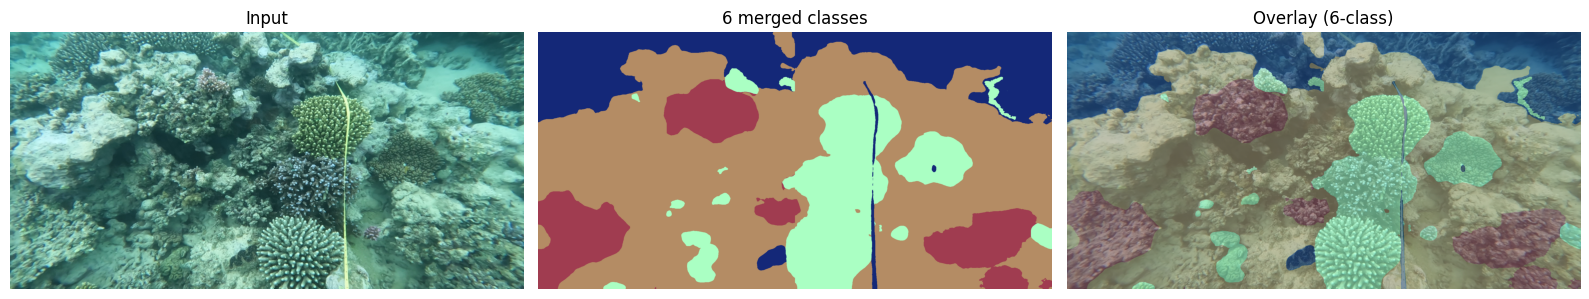

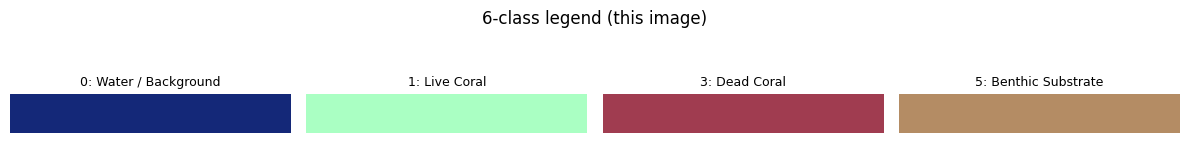

In [14]:
import sys

sys.path.insert(0, str(PROJECT_ROOT / "lib"))
from coralscapes_6class_lut import build_lut, remap_mask

CLASSES_6_PATH = PROJECT_ROOT / "data" / "coralscapes_6class_dataset" / "classes_6.json"
name_to_id_6: dict[str, int] = json.loads(CLASSES_6_PATH.read_text(encoding="utf-8"))
id2label_6 = {v: k for k, v in name_to_id_6.items()}

# Distinct RGB for visualization (class 0 = water/background)
id2color_6 = {
    0: [20, 40, 120],
    1: [170, 255, 195],  # live coral — light green
    2: [255, 220, 100],
    3: [160, 60, 80],
    4: [12, 85, 35],  # algae — dark green
    5: [180, 140, 100],
}

_lut6 = build_lut(max_class_id=255)
seg6 = remap_mask(seg.astype(np.uint8), _lut6)

u6, c6 = np.unique(seg6, return_counts=True)
print("6-class map (after merging 40-way predictions):")
for u, c in zip(u6, c6):
    print(f"  {int(u)}  {100.0 * float(c) / seg6.size:5.2f}%  {id2label_6[int(u)]}")

# Class 0 (water/background): keep original pixels — only paint classes 1–5
base_rgb = np.array(image.convert("RGB"), dtype=np.float32)
colored6 = base_rgb.copy()
for _cid in range(1, 6):
    _m = seg6 == _cid
    colored6[_m] = id2color_6[_cid]
colored6 = np.clip(colored6, 0, 255).astype(np.uint8)

_alpha = 0.5
overlay6 = base_rgb.copy()
for _cid in range(1, 6):
    _m = seg6 == _cid
    _col = np.array(id2color_6[_cid], dtype=np.float32)
    overlay6[_m] = (1 - _alpha) * overlay6[_m] + _alpha * _col
overlay6 = np.clip(overlay6, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(image)
axes[0].set_title("Input")
axes[0].axis("off")
axes[1].imshow(colored6)
axes[1].set_title("Classes 1–5 only (0 = photo)")
axes[1].axis("off")
axes[2].imshow(overlay6)
axes[2].set_title("Overlay (1–5 only)")
axes[2].axis("off")
plt.tight_layout()
plt.show()

# Legend: segmented classes only (exclude 0 / water–background)
present6 = sorted(int(x) for x in u6 if int(x) != 0)
if present6:
    fig, axes = plt.subplots(1, len(present6), figsize=(3 * len(present6), 1.2))
    if len(present6) == 1:
        axes = [axes]
    for ax, cid in zip(axes, present6):
        col = np.array(id2color_6[cid], dtype=np.float32) / 255.0
        ax.add_patch(plt.Rectangle((0, 0), 1, 1, color=col))
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.axis("off")
        ax.set_title(f"{cid}: {id2label_6[cid]}", fontsize=9)
    plt.suptitle("Legend: classes 1–5 present in this image", y=1.15)
else:
    fig, ax = plt.subplots(figsize=(4, 1))
    ax.text(0.5, 0.5, "No foreground classes (1–5) in this image", ha="center", va="center")
    ax.axis("off")
plt.tight_layout()
plt.show()

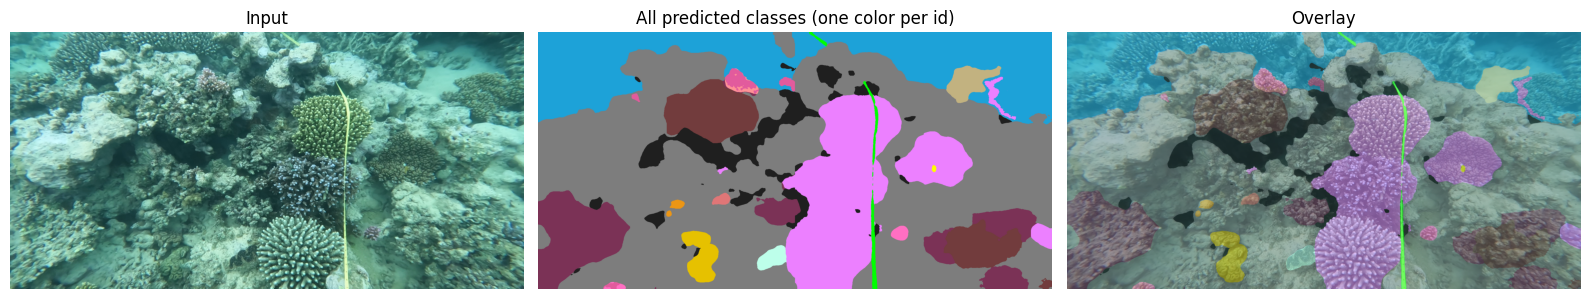

In [15]:
colored = colorize_mask(seg, id2color)
overlay = mask_to_overlay(image, colored, alpha=0.5)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(image)
axes[0].set_title("Input")
axes[0].axis("off")
axes[1].imshow(colored)
axes[1].set_title("All predicted classes (one color per id)")
axes[1].axis("off")
axes[2].imshow(overlay)
axes[2].set_title("Overlay")
axes[2].axis("off")
plt.tight_layout()
plt.show()

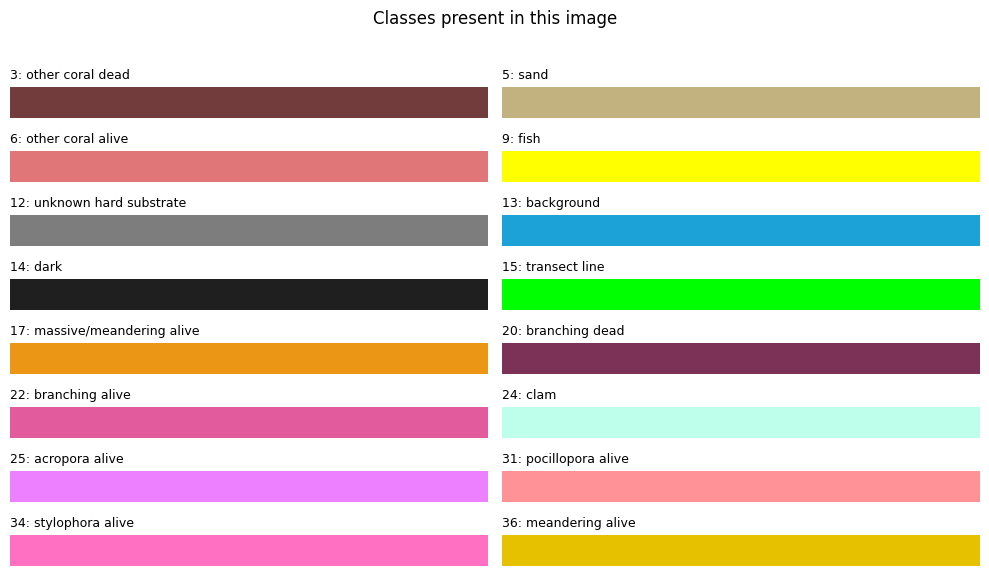

In [16]:
# Legend for classes that appear in this prediction (full 40-class legend can be huge)
present = sorted(int(x) for x in np.unique(seg))
ncols = 2
nrows = (len(present) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(10, max(2, 0.35 * len(present))))
axes = np.atleast_1d(axes).ravel()
for ax in axes[len(present) :]:
    ax.axis("off")
for ax, cid in zip(axes, present):
    col = np.array(id2color[cid], dtype=np.float32) / 255.0
    ax.add_patch(plt.Rectangle((0, 0), 1, 1, color=col))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    ax.set_title(f"{cid}: {id2label.get(cid, '?')}", fontsize=9, loc="left")
plt.suptitle("Classes present in this image", y=1.02)
plt.tight_layout()
plt.show()

In [14]:
def segment_single_forward(
    image: Image.Image,
    preprocessor: SegformerImageProcessor,
    model: SegformerForSemanticSegmentation,
) -> np.ndarray:
    with torch.inference_mode():
        inputs = preprocessor(images=image, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}
        outputs = model(**inputs)
        seg = preprocessor.post_process_semantic_segmentation(
            outputs, target_sizes=[image.size[::-1]]
        )[0]
    return np.array(seg, dtype=np.int32)


# seg_fast = segment_single_forward(image, processor, model)